In [2]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
# 선형회귀를 위한 참조
import statsmodels.api as sm
from statsmodels.formula.api import ols
# 결과 검정을 위한 참조
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, probplot, shapiro, anderson
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
# VIF값을 계산하기 위한 참조
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns

In [3]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [4]:
origin = load_data("california_housing")

print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/kaggle/california_housing.xlsx
[desc] 1990년 미국 인구조사(Census)를 기반으로 캘리포니아 각 지역의 인구·주택·소득 특성과 주택 중위가격을 담아, 회귀 분석과 머신러닝 모델 실습에 널리 사용되는 대표적인 주택 가격 데이터 (출처: https://www.kaggle.com/datasets/camnugent/california-housing-prices)

field               description
------------------  ------------------------------------------------------------------------------
longitude           경도(Longitude). 서경(–값) 기준.
latitude            위도(Latitude). 북위(+) 기준.
housing_median_age  해당 구역(블록 그룹)의 주택 중위 연령(년).
total_rooms         구역 내 모든 주택의 총 방(room) 수 합계.
total_bedrooms      구역 내 모든 주택의 총 침실(bedroom) 수 합계.
population          구역의 전체 인구 수.
households          구역의 전체 “가구 수”(living units).
median_income       구역의 중위 소득(median income), 단위는 약 1 = $10,000 수준.
median_house_value  주택 중위가격(달러). 회귀의 목표변수(타깃).
ocean_proximity     해안과의 거리/접근성 범주: <1H OCEAN, INLAND, NEAR BAY, NEAR OCEAN, ISLAND 등.


===== 데이터 크기 확인 =====
데이터셋 크기: (20640, 10)
열 개수: 10
행 개수: 20640

===== 타입확인 =====
<class '

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


미션1_“이 데이터는 믿을 만할까?”
결측·이상치·편향을 점검하고, 처리 기준을 제시한다.<br>
MedHouseValue가 0이거나 극단값인지, MedInc/HouseAge/AveRooms 등 주요 변수의 범위가 현실적인지 확
인한다.<br>
1940년 이전 건축 주택이 52로 코딩되는 이유를 이해하고, 분석에 미칠 영향을 검토한다.<br>
전처리 전·후가 어떻게 달라졌는지 한눈에 비교하는 표나 요약을 만든다.<br>
단위·해석 주의: MedHouseValue는 실제 달러 단위입니다. 1990년 명목가를 참고해 현실성을 평가하세요.<br>
📌 출제 의도 “이 값이 말이 되나?”를 먼저 묻고, 어떻게 처리했는지를 기록해 나중 해석에 근거를 남기는 연습입니
다

In [5]:
# median_house_value 를 예측하기 위해 median_income, housing_median_age, ave_rooms의 사분위수 분포 구함
col_desc = {
    'longitude': '경도(Longitude). 서경(-값) 기준.',
    'latitude': '위도(Latitude). 북위(+) 기준.',
    'housing_median_age': '해당 구역(블록 그룹)의 주택 중위 연령(년).',
    'total_rooms': '구역 내 모든 주택의 총 방(room) 수 합계.',
    'total_bedrooms': '구역 내 모든 주택의 총 침실(bedroom) 수 합계.',
    'population': '구역의 전체 인구 수.',
    'households': '구역의 전체 가구 수(living units).',
    'median_income': '구역의 중위 소득(median income), 단위는 약 1 = $10,000.',
    'median_house_value': '주택 중위가격(달러). 회귀의 목표변수(타깃).',
    'ocean_proximity': '해안과의 거리/접근성 범주.'
}

df = origin.copy()

df["ave_rooms"] = df["total_rooms"] / df["households"]



for col, desc in col_desc.items():
    print(f'[{col}]')
    print(desc)
    print('-' * 60)

vars_of_interest = [
    "median_house_value",
    "median_income",
    "housing_median_age",
    "ave_rooms",
    
]


print(f"52라는 수치가 존재하는 이유는, 상한 포화 문제 때문에 그렇다.\n")
df[vars_of_interest].describe(percentiles=[0.25, 0.5, 0.75])


[longitude]
경도(Longitude). 서경(-값) 기준.
------------------------------------------------------------
[latitude]
위도(Latitude). 북위(+) 기준.
------------------------------------------------------------
[housing_median_age]
해당 구역(블록 그룹)의 주택 중위 연령(년).
------------------------------------------------------------
[total_rooms]
구역 내 모든 주택의 총 방(room) 수 합계.
------------------------------------------------------------
[total_bedrooms]
구역 내 모든 주택의 총 침실(bedroom) 수 합계.
------------------------------------------------------------
[population]
구역의 전체 인구 수.
------------------------------------------------------------
[households]
구역의 전체 가구 수(living units).
------------------------------------------------------------
[median_income]
구역의 중위 소득(median income), 단위는 약 1 = $10,000.
------------------------------------------------------------
[median_house_value]
주택 중위가격(달러). 회귀의 목표변수(타깃).
------------------------------------------------------------
[ocean_proximity]
해안과의 거리/접근성 범주.
------------------------------

,median_house_value,median_income,housing_median_age,ave_rooms
count,20640.000000,20640.000000,20640.000000,20640.000000
mean,206855.816909,3.870671,28.639486,5.429000
std,115395.615874,1.899822,12.585558,2.474173
min,14999.000000,0.499900,1.000000,0.846154
25%,119600.000000,2.563400,18.000000,4.440716
50%,179700.000000,3.534800,29.000000,5.229129
75%,264725.000000,4.743250,37.000000,6.052381
max,500001.000000,15.000100,52.000000,141.909091


In [6]:
(df["median_house_value"]==500001).mean()

np.float64(0.04675387596899225)

전처리 전/후 비교용 요약표

In [7]:
import pandas as pd
summary_before = df[vars_of_interest].quantile([0.25, 0.5, 0.75])

# 예: avg_rooms 이상치 컷
df_clean = df[df["ave_rooms"] < 10]

summary_after = df_clean[vars_of_interest].quantile([0.25, 0.5, 0.75])

pd.concat(
    {"before": summary_before, "after": summary_after},
    axis=1
)


before                                             \
     median_house_value median_income housing_median_age ave_rooms   
0.25           119600.0       2.56340               18.0  4.440716   
0.50           179700.0       3.53480               29.0  5.229129   
0.75           264725.0       4.74325               37.0  6.052381   

                  after                                             
     median_house_value median_income housing_median_age ave_rooms  
0.25           119800.0        2.5625               18.0  4.432065  
0.50           180400.0        3.5341               29.0  5.213198  
0.75           265200.0        4.7426               37.0  6.016000

📝 미션 2. “가격과 핵심 변수의 첫인상”<br>
MedHouseValue, MedInc, HouseAge, AveRooms 분포를 히스토그램/KDE로 확인하고 알 수 있는 객관적 사
실을 서술한다.<br>
왜도/이상치가 회귀에 줄 수 있는 영향과 변환할 필요가 있는지 서술하시오.<br>
분포 비교는 동일 축 스케일로 제시하고, 평균/중앙값/꼬리의 차이를 문장으로 요약하세요.<br>
지역별(Latitude/Longitude) 편향이나 시계열 문제(1990년 데이터만)가 해석에 미치는 영향도 짧게 언급하세요.<br>
📌 출제 의도 목표변수·핵심 변수의 생김새를 먼저 읽고 변환 필요성을 스스로 판단하게 합니다. 숫자보다 해석 문
장이 중요합니다

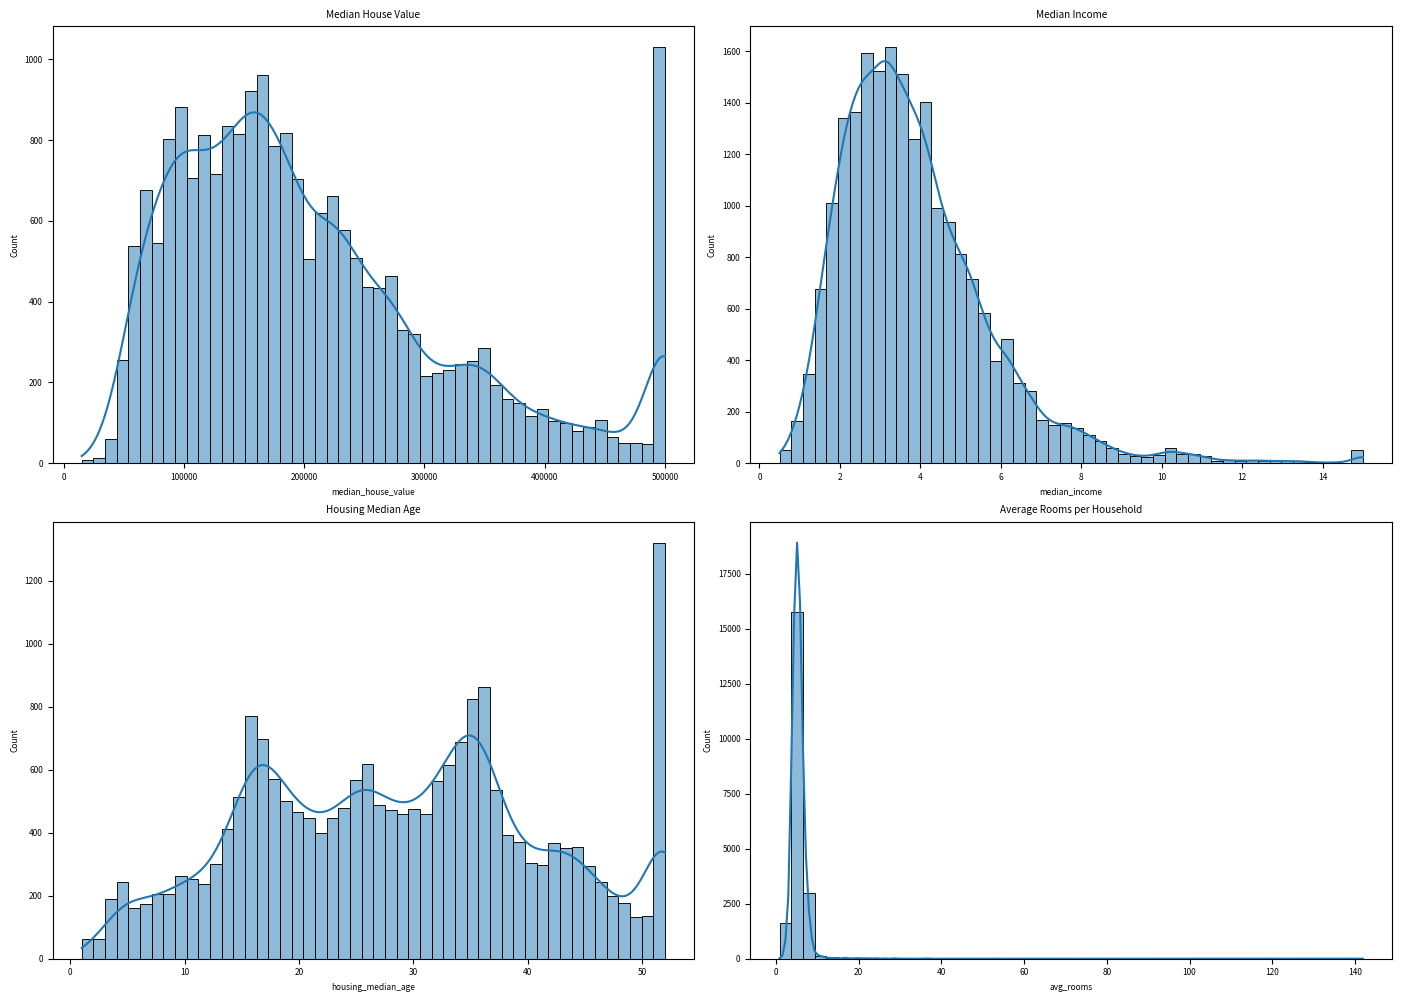

=====Median House Value=====
강한 우측 꼬리
평균은 상단 값에 끌려 왜곡
선형 회귀에서:잔차 비정상성,고가 예측 한계 발생 가능

=====Medianincom=====
우측으로 긴 꼬리
저소득 구간에 밀집, 고소득은 희소
전형적인 경제 변수 분포

=====Housing Median Age=====
1~52까지 비교적 고르게 분포
52에서 강한 수직 스파이크
52는 52년 된 집이 아니라 1940년 이전 건축을 하나로 묶은 코드
연속형 변수처럼 보이지만 사실상:
연속+범주가 섞인 혼합 변수
평균/분산 해석이 왜곡됨

=====AVG Rooms=====
중심은 3~6
우측 꼬리가 김
극단값(10~20+)존재
왜?
households가 매우 작은 지역
total_rooms는 큰 경우 발생
수학적 비율 변수의 전형적 이상치


In [8]:
import seaborn as sb
import matplotlib.pyplot as plt
my_dpi = 100
rows, cols = 2, 2

fig, axes = plt.subplots(
    rows, cols,
    figsize=(14, 10),
    dpi=my_dpi
)

df["avg_rooms"] = df["total_rooms"] / df["households"]

axes = axes.flatten()

vars_info = [
    ("median_house_value", "Median House Value"),
    ("median_income", "Median Income"),
    ("housing_median_age", "Housing Median Age"),
    ("avg_rooms", "Average Rooms per Household")
]

for ax, (col, title) in zip(axes, vars_info):
    sb.histplot(
        data=df,
        x=col,
        bins=50,
        kde=True,
        ax=ax,
        
    )
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()
print(f"=====Median House Value=====\n강한 우측 꼬리\n평균은 상단 값에 끌려 왜곡\n선형 회귀에서:잔차 비정상성,고가 예측 한계 발생 가능\n\n=====Medianincom=====\n우측으로 긴 꼬리\n저소득 구간에 밀집, 고소득은 희소\n전형적인 경제 변수 분포\n\n=====Housing Median Age=====\n1~52까지 비교적 고르게 분포\n52에서 강한 수직 스파이크\n52는 52년 된 집이 아니라 1940년 이전 건축을 하나로 묶은 코드\n연속형 변수처럼 보이지만 사실상:\n연속+범주가 섞인 혼합 변수\n평균/분산 해석이 왜곡됨"
      f"\n\n=====AVG Rooms=====\n중심은 3~6\n우측 꼬리가 김\n극단값(10~20+)존재\n왜?\nhouseholds가 매우 작은 지역\ntotal_rooms는 큰 경우 발생\n수학적 비율 변수의 전형적 이상치")

-----시계열-----<br>
📌Latitude/Longitude<br>
캘리포니아는<br>
해안 vs 내륙<br>
북부 vs 남부<br>
분포 왜곡의 상당 부분은 공간적 요인<br><br>

📌시계열 문제<br>
데이터 기준:1990년 Census<br>
현재 가격 수준과 직접 비교 불가<br>
해석은 반드시:<br>
"19190년 당시 상대적 가격" 기준

-----결론-----<br>
본 데이터의 핵심 변수들은 대부분<br>
비대칭 분포, 상한 처리, 이상치를 포함하고 있어<br>
단순 평균 기반 해석이나<br>
변환 없는 회귀 분석에 적합하지 않다.<br>
따라서 목표 변수와 설명 변수의 분포 특성을 먼저 이해하고,<br>
로그변환, 구간화, 더미 분리 등의 전처리를 통해<br>
모델 해석 가능성을 확보하는 것이 필수적

📝 미션 3. “로그/비선형 변환을 고민해 보자”<br>
MedHouseValue 혹은 주요 변수(MedInc, Population,HouseAge)<br>에 로그/제곱근 등 변환을 적용해 전후 분포
를 나란히 비교한다.<br>
변환이 해석과 모델 적합에 주는 장단점, 해석이 어떻게 달라지는지 예상한다.<br>
“이 변환이 없으면 어떤 함정에 빠질까?”를 한 줄로 정리한다.<br>
선택 기준을 명시하세요: 왜 log(MedHouseValue)인지,<br>
왜 Population에 로그인지 등 데이터 분포 근거로 설명합니다.<br>
필요한 경우 Box-Cox 등의 변환을 비교해 가장 해석 친화적인 옵션을 선택하세요.<br>
📌 출제 의도 단순히 변환을 쓰는 것이 아니라 “왜 필요했는가, 해석이 어떻게 달라지는가”를 설명하는 연습입니다.<br>

1. 핵심 가설 설정 (분석 전에 반드시 필요)<br>
가설 A (구조적 가설)<br>

오래된 주택일수록<br>

가구 수 대비 방 수가 작거나<br>

침실 비율이 다르거나<br>

주거 밀도가 다르다<br>

즉, housing_median_age는 단독 변수라기보다<br>
주거 구조 변수들과 “결합될 때” 의미를 갖는다는 가설입니다.

In [9]:
# 파생 변수 생성
df = origin.copy()

df["avg_rooms"] = df["total_rooms"] / df["households"]
df["avg_bedrooms"] = df["total_bedrooms"] / df["households"]
df["bedroom_ratio"] = df["total_bedrooms"] / df["total_rooms"]

# housing_median_age를 "연속값"이 아니라 "구간"으로 본다
df["age_bin"] = pd.qcut(
    df["housing_median_age"],
    q=4,
    labels=["Q1(young)", "Q2", "Q3", "Q4(old)"]
)
print(f"Q4가 반드시 52만 있는지\nQ1~Q3 내부 분산이 구조 변수로 설명되는지")

Q4가 반드시 52만 있는지
Q1~Q3 내부 분산이 구조 변수로 설명되는지


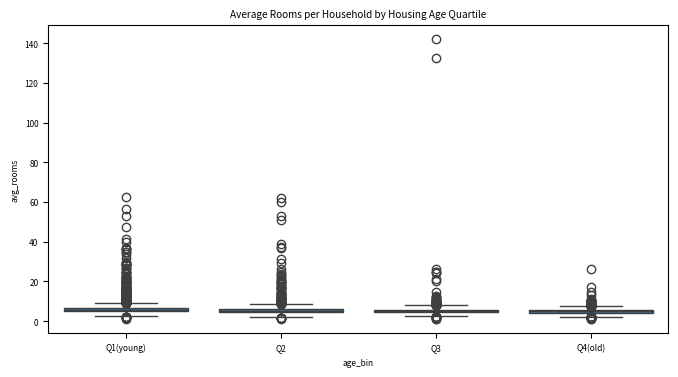

In [10]:
# age_bin vs avg_rooms
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.boxplot(x="age_bin", y="avg_rooms", data=df)
plt.title("Average Rooms per Household by Housing Age Quartile")
plt.show()


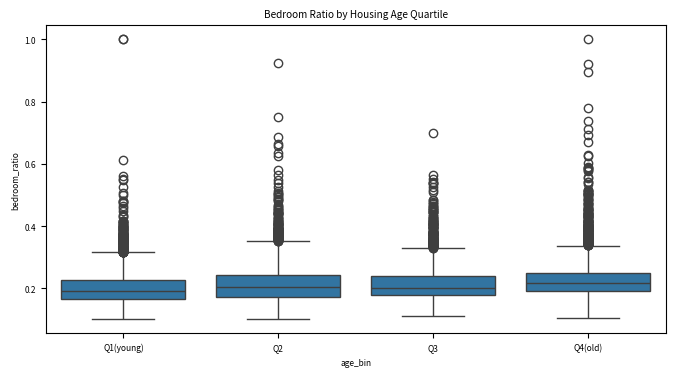

In [11]:
# age_bin vs bedroom_ratio
plt.figure(figsize=(8, 4))
sns.boxplot(x="age_bin", y="bedroom_ratio", data=df)
plt.title("Bedroom Ratio by Housing Age Quartile")
plt.show()


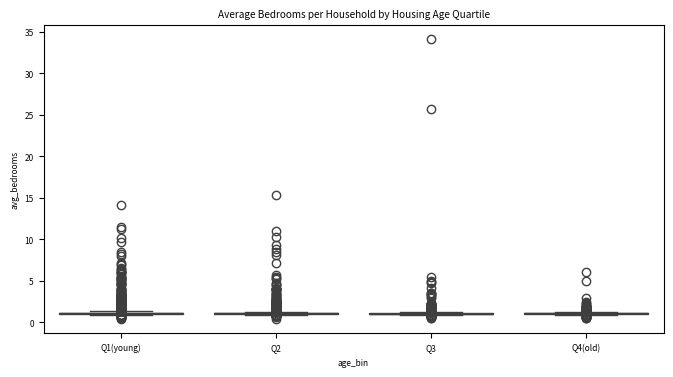

In [12]:
# age_bin vs avg_bedrooms
plt.figure(figsize=(8, 4))
sns.boxplot(x="age_bin", y="avg_bedrooms", data=df)
plt.title("Average Bedrooms per Household by Housing Age Quartile")
plt.show()


경우 ①<br>

age가 증가할수록 avg_rooms가 감소<br>

오래된 지역 = 소형 주택 위주<br>

age 분산은 실제 도시 구조 차이<br>

→ housing_median_age는 의미 있는 설명 변수<br><br>

경우 ②<br>

age와 구조 변수 간 차이가 거의 없음<br>
분산은 행정 단위/코딩 단위 노이즈<br>

→ housing_median_age 단독 사용 위험<br>

→ 다른 변수와의 interaction 필요<br><br>


경우 ③<br>

Q4(52)에서만 구조가 급격히 달라짐<br>

“1940년 이전”이라는 역사적 단층<br>

→ age_is_capped 이진 변수 도입 타당

In [13]:
# 정량적 검증(상관 + 분산 설명)
df[[
    "housing_median_age",
    "avg_rooms",
    "avg_bedrooms",
    "bedroom_ratio"
]].corr()


,housing_median_age,avg_rooms,avg_bedrooms,bedroom_ratio
housing_median_age,1.000000,-0.153277,-0.077918,0.136089
avg_rooms,-0.153277,1.000000,0.848616,-0.416952
avg_bedrooms,-0.077918,0.848616,1.000000,0.055905
bedroom_ratio,0.136089,-0.416952,0.055905,1.000000


구조 변수 × 가격의 interaction term

In [14]:
# 구조 변수 생성
df = origin.copy()

df["avg_rooms"] = df["total_rooms"] / df["households"]
df["avg_bedrooms"] = df["total_bedrooms"] / df["households"]
df["bedroom_ratio"] = df["total_bedrooms"] / df["total_rooms"]


In [15]:
# age 상한을 분리
df["age_is_capped"] = (df["housing_median_age"] == 52).astype(int)


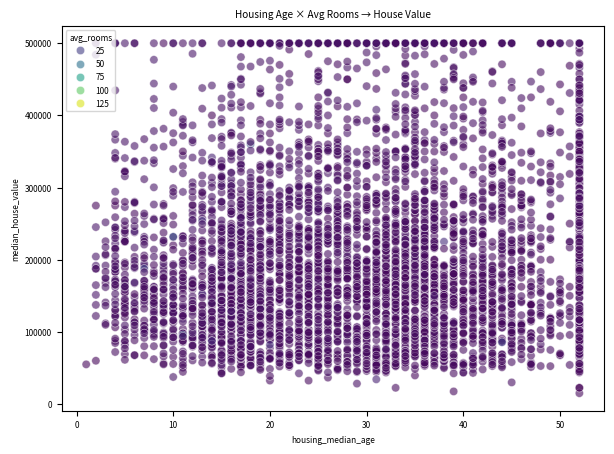

-----중요-----
housing_median_age와 avg_rooms는 주택 가격에 대해 직접적,단독적 선형 관계를 가지는 않지만,
다른 핵심 변수(특히 소득,지역)와 결합될 때
가격 분산의 구조를 설명하는 조건부 변수로 작용


In [16]:
# 1차 시각 분석: 구조 × 가격
# housing_median_age × avg_rooms → 가격
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="housing_median_age",
    y="median_house_value",
    hue="avg_rooms",
    palette="viridis",
    alpha=0.6
)
plt.title("Housing Age × Avg Rooms → House Value")
plt.show()
print(f"-----중요-----\nhousing_median_age와 avg_rooms는 주택 가격에 대해 직접적,단독적 선형 관계를 가지는 않지만,\n다른 핵심 변수(특히 소득,지역)와 결합될 때\n가격 분산의 구조를 설명하는 조건부 변수로 작용")


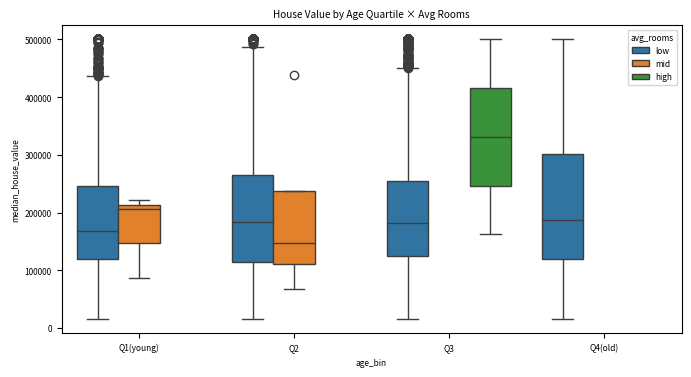

In [17]:
# age 구간별 avg_rooms × 가격
df["age_bin"] = pd.qcut(
    df["housing_median_age"],
    q=4,
    labels=["Q1(young)", "Q2", "Q3", "Q4(old)"]
)

plt.figure(figsize=(8, 4))
sns.boxplot(
    x="age_bin",
    y="median_house_value",
    hue=pd.cut(df["avg_rooms"], bins=3, labels=["low", "mid", "high"]),
    data=df
)
plt.title("House Value by Age Quartile × Avg Rooms")
plt.show()


예상대로 방 수가 많은 주택의 주택 중위 가격이 높았음.<br>
또한, 최신형 주택일 때 방 수가 적은 박스플롯이 방 수가 low보다 많은 mid보다 사분위수 구간이 더 낮은 쪽에 위치함에도 불구하고 mid와 달리 이상치가 발견된 것에 의문<br>


In [18]:
# median_income 사분위 구간 생성
df = origin.copy()

# Low income, Mid-low, Mid-high, High income으로 나눔
df["income_bin"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low income", "Mid-Low", "Mid-High", "High income"]
)



C:\Users\itwill\AppData\Local\Temp\ipykernel_22816\4202915544.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\itwill\AppData\Local\Temp\ipykernel_22816\4202915544.py:9: UserWarning: The palette list has more values (9) than needed (4), which may not be intended.
  sns.boxplot(


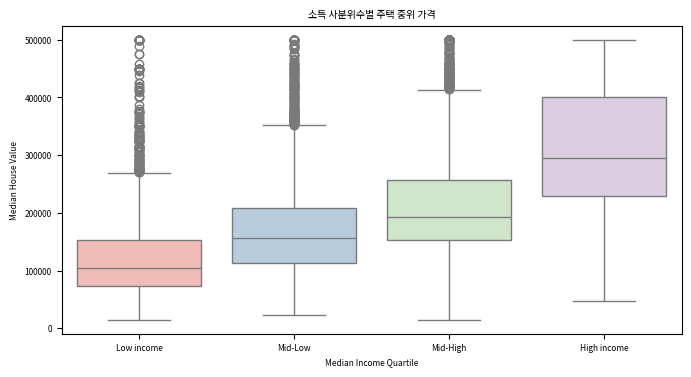

In [19]:
df["income_bin"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low income", "Mid-Low", "Mid-High", "High income"]
)

palette = sns.color_palette('Pastel1')
plt.figure(figsize=(8, 4))
sns.boxplot(
    x="income_bin",
    y="median_house_value",
    data=df,
    palette = palette
)

plt.title("소득 사분위수별 주택 중위 가격")
plt.xlabel("Median Income Quartile")
plt.ylabel("Median House Value")
plt.show()


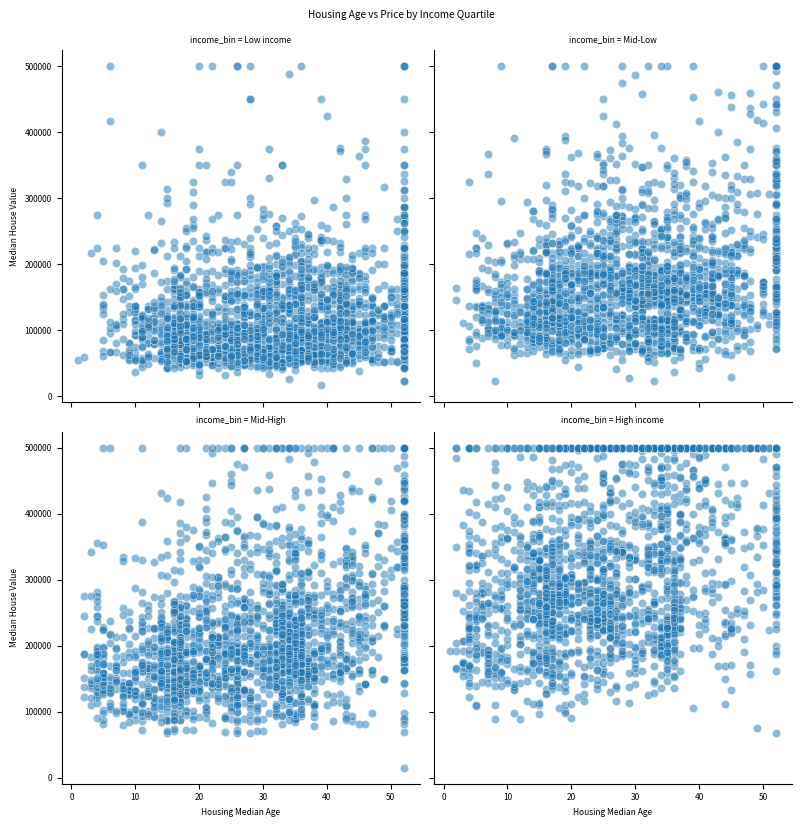

-----가격의 분산 구조-----
같은 소득 수준에서, 주택 연령이 가격 분포에 어떤 역할을 하는가소득이 통제된 상태에서의 조건부 현상

income_bin이 Mid_High인 패널에에서는 소득자체가 고가 형성을 허용함.
즉, 가격 상한이 열린 상태
오래된 집 중에서도 입지 좋고 역사적 주거지인 곳들이 고가로 남아있음
고소득 지역에서는 오래된 집도 비쌀 수 있다

Low income일 경우
가격 상단이 약 200k 전후에서 제한
age증가에도 상단이 거의 안 움직임
분산도 비교적 작음
-->소득이 낮으면 오래된 집이여도 고가 형성 불가
Mid-Low income일 경우
가격 상단이 약 300k까지 확장
age 증가와 함께 분산이 약간 커짐
age가 단독 요인으로 작동하기 시작
하지만 여전히 소득이 가격을 지배

Mid-High income일 경우
상단이 400~500k까지 열림
age 20~40구간에서 고가 밀집
주택 연령이 노후가 아니라 성숙한 주거지를 의미하는 구간 존재
age효과가 비선형적

High income
전 연령대에서 고가 존재
52(상한)에서 고가가 집중
분산이 매우 큼


In [20]:
# 소득 구간별로 age x price 산점도
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    df.sample(8000, random_state=42),
    col="income_bin",
    col_wrap=2,
    height=4,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="housing_median_age",
    y="median_house_value",
    alpha=0.5
)

g.set_axis_labels("Housing Median Age", "Median House Value")
g.fig.suptitle("Housing Age vs Price by Income Quartile", y=1.02)

plt.show()
print(f"-----가격의 분산 구조-----\n같은 소득 수준에서, 주택 연령이 가격 분포에 어떤 역할을 하는가"
      f"소득이 통제된 상태에서의 조건부 현상\n\nincome_bin이 Mid_High인 패널에에서는 소득자체가 고가 형성을 허용함.\n즉, 가격 상한이 열린 상태\n오래된 집 중에서도 입지 좋고 역사적 주거지인 곳들이 고가로 남아있음\n고소득 지역에서는 오래된 집도 비쌀 수 있다"
      f"\n\nLow income일 경우\n가격 상단이 약 200k 전후에서 제한\nage증가에도 상단이 거의 안 움직임\n분산도 비교적 작음\n-->소득이 낮으면 오래된 집이여도 고가 형성 불가"
      f"\nMid-Low income일 경우\n가격 상단이 약 300k까지 확장\nage 증가와 함께 분산이 약간 커짐\nage가 단독 요인으로 작동하기 시작\n하지만 여전히 소득이 가격을 지배"
      f"\n\nMid-High income일 경우\n상단이 400~500k까지 열림\nage 20~40구간에서 고가 밀집\n주택 연령이 노후가 아니라 성숙한 주거지를 의미하는 구간 존재\nage효과가 비선형적"
      f"\n\nHigh income\n전 연령대에서 고가 존재\n52(상한)에서 고가가 집중\n분산이 매우 큼")

High income일수록 지역적 특징(보조변수)에 따라서 주택 중위가격이 달라진다?

📝미션 5. “소득은 정말로 집값을 결정할까?”MedInc(중위가구소득)에 따라 MedHouseValue가 다른지 시각화하고,<br>선형성과 강도를 평가한다.<br>산점도와 함께 회귀선을 그려 관계의 형태를 관찰하세요.<br>상관계수(Pearson)를 계산하고,<br>“정말로 소득이 집값의 주 결정 요인인가?”를 비판적으로 생각해 보자.<br>소득 수준에 따른 주택가격 불평등 문제를 해석 관점에서 논의하세요

In [21]:
# Pearson 상관계수 계산 (정량 검증)
# 전체 상관계수
print(f"보통 0.6~0.7 수준의 강한 양의 상관")
df[["median_income", "median_house_value"]].corr(method="pearson")


보통 0.6~0.7 수준의 강한 양의 상관


,median_income,median_house_value
median_income,1.000000,0.688075
median_house_value,0.688075,1.000000


In [22]:
# 소득 구간별 상관계수
df.groupby("income_bin")[["median_income", "median_house_value"]].corr()


C:\Users\itwill\AppData\Local\Temp\ipykernel_22816\2974317571.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("income_bin")[["median_income", "median_house_value"]].corr()


median_income  median_house_value
income_bin                                                       
Low income  median_income            1.000000            0.134015
            median_house_value       0.134015            1.000000
Mid-Low     median_income            1.000000            0.159523
            median_house_value       0.159523            1.000000
Mid-High    median_income            1.000000            0.150028
            median_house_value       0.150028            1.000000
High income median_income            1.000000            0.598924
            median_house_value       0.598924            1.000000

전체 상관은 높지만,<br>

소득 분위 내부에서는 상관이 급격히 약화<br>

즉, 집단 간 효과(between-group effect) 가 크다<br>

👉Simpson’s Paradox 가능성을 강하게 시사

본 분석에서<br> median_income은median_house_value와 높은<br> Pearson 상관을 보이나,<br>
이는 소득이 주택 가격을 직접 결정한다기보다<br>
가격 분산이 허용되는 구조적 범위를 규정하는 조건 변수로 작용함을 시사한다.<br>
소득 분위 내부에서는 가격 변동성이 크게 줄어들며,
위치·주택 구조·연령과 같은 요인이 상대적으로 더 중요한 설명력을 가진다.<br>

📝미션 6. “주택 특성은 소수일까, 다수일까?”<br>
AveRooms, AveBedrms, HouseAge, AveOccup, Population의 분포를 확인한다.<br>
각 변수별로 생존자(정상) vs 이상치를 구분하고, 회귀에 미칠 영향을 평가하세요.<br>
일부 극단값(예: 매우 작은 방의 수, 매우 높은 인구밀도)이 전체 분석을 왜곡할 가능성을 검토합니다.
📌출제 의도 다양한 설명 변수의 생김새를 한눈에 이해하고, 각각이 가진 특성(분포, 이상치)을 인식하게 합니다.

In [24]:
df = origin.copy()

df["avg_rooms"] = df["total_rooms"] / df["households"]
df["avg_bedrooms"] = df["total_bedrooms"] / df["households"]
df["ave_occup"] = df["population"] / df["households"]


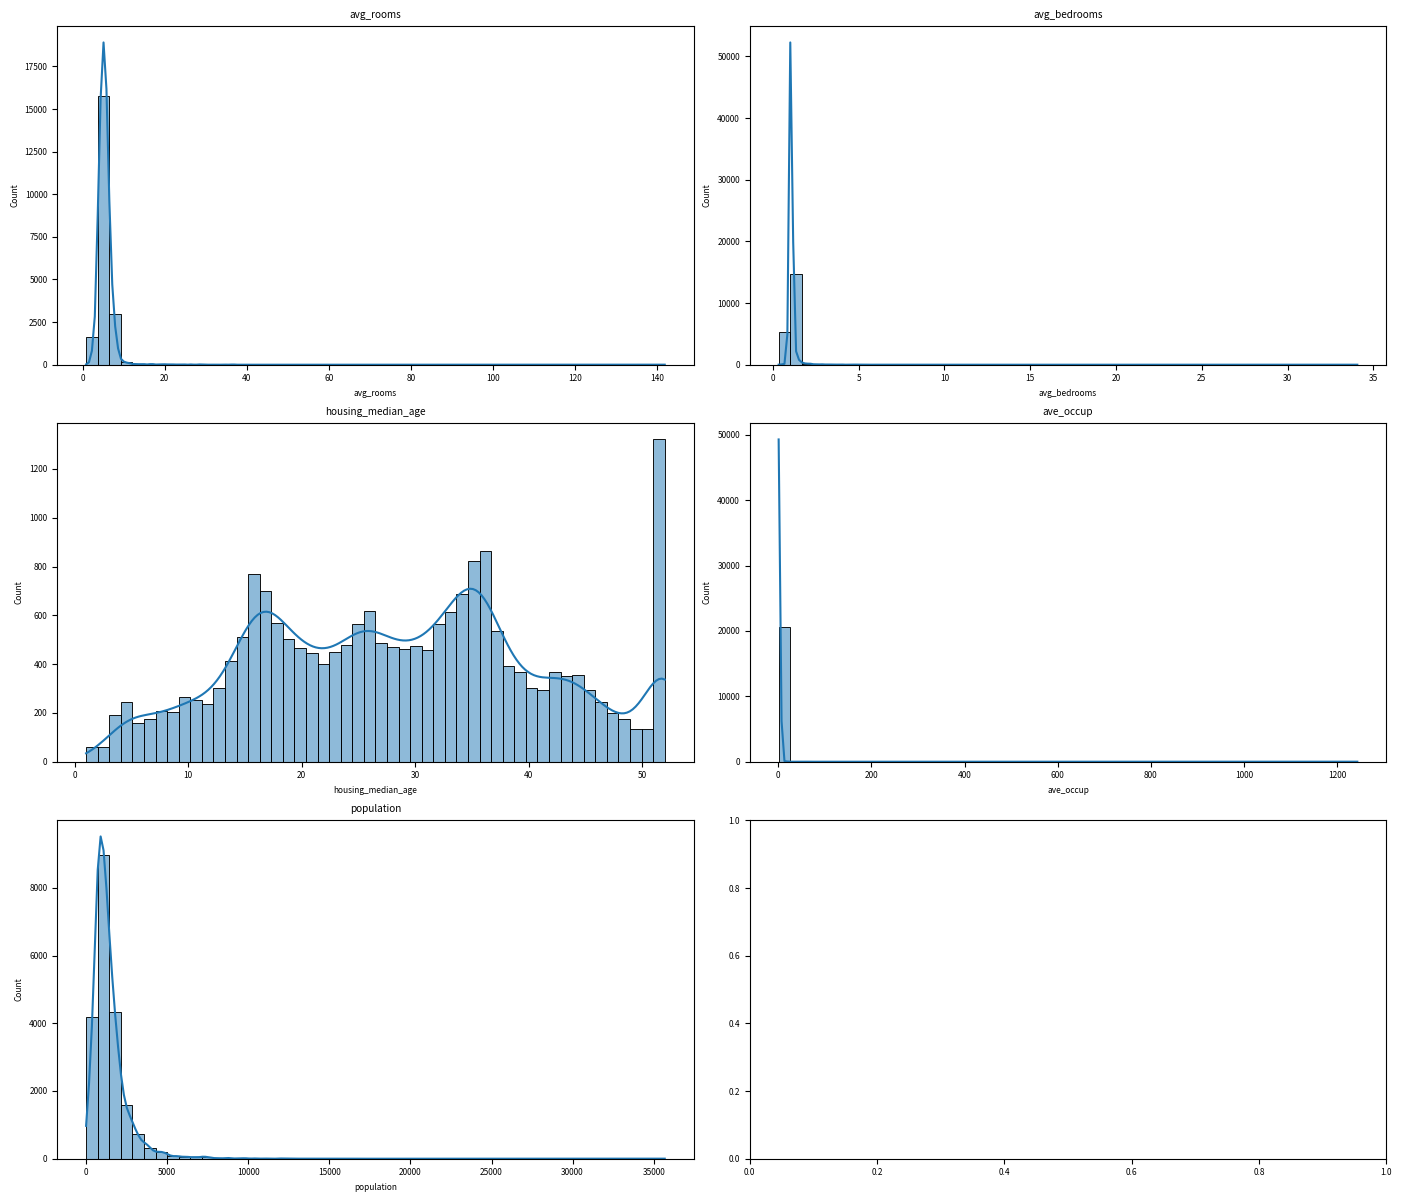

In [ ]:
# 분포 확인:히스토그램 +  KDE(정규성 직관 확인)
vars_ = ["avg_rooms", "avg_bedrooms", "housing_median_age", "ave_occup", "population"]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, col in zip(axes, vars_):
    sns.histplot(
        data=df,
        x=col,
        bins=50,
        kde=True,
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()
print(f"🔹(1) AveRooms\n중심: 3~6\n우측 꼬리 매우 김\n20, 50, 100 이상 값 존재\n✅ 로그 변환 or 상한 컷 필요\n잔차 비정상성\n특정 관측치가 계수 지배"
      f"🔹(2) AveBedrms\navg_rooms와 거의 동일한 분포 형태\n상관계수 ≈ 0.85 이상\n"
      f"🔹(3) HousingAge\n1~52 비교적 고르게 분포\n52에서 인위적 스파이크\n"

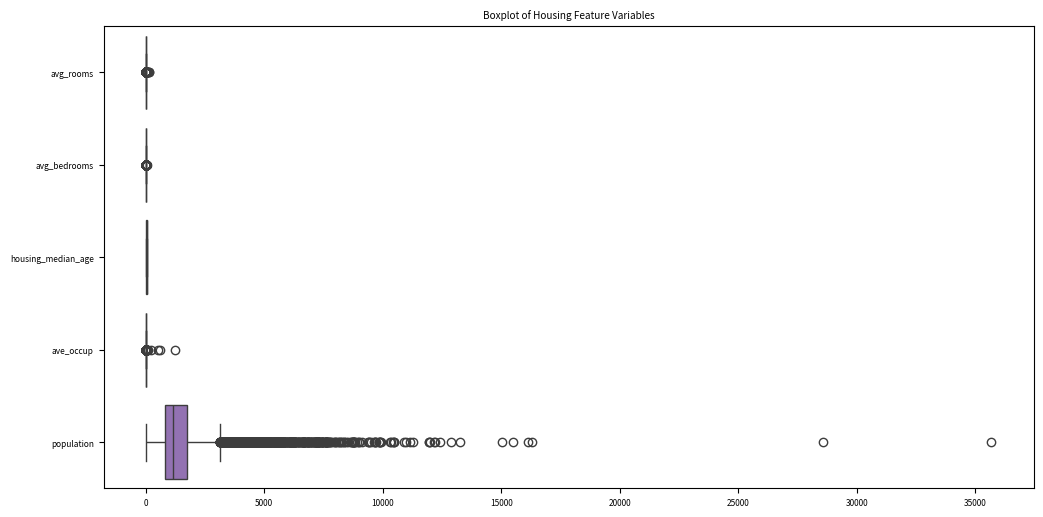

In [33]:
# 박스플롯: 이상치 구조 확인 (핵심)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[vars_], orient="h")
plt.title("Boxplot of Housing Feature Variables")
plt.show()


In [36]:
for col, desc in col_desc.items():
    print(f'[{col}]')
    print(desc)
    print('-' * 60)




[longitude]
경도(Longitude). 서경(-값) 기준.
------------------------------------------------------------
[latitude]
위도(Latitude). 북위(+) 기준.
------------------------------------------------------------
[housing_median_age]
해당 구역(블록 그룹)의 주택 중위 연령(년).
------------------------------------------------------------
[total_rooms]
구역 내 모든 주택의 총 방(room) 수 합계.
------------------------------------------------------------
[total_bedrooms]
구역 내 모든 주택의 총 침실(bedroom) 수 합계.
------------------------------------------------------------
[population]
구역의 전체 인구 수.
------------------------------------------------------------
[households]
구역의 전체 가구 수(living units).
------------------------------------------------------------
[median_income]
구역의 중위 소득(median income), 단위는 약 1 = $10,000.
------------------------------------------------------------
[median_house_value]
주택 중위가격(달러). 회귀의 목표변수(타깃).
------------------------------------------------------------
[ocean_proximity]
해안과의 거리/접근성 범주.
------------------------------

📝미션 7. “소득과 다른 특성은 독립적일까?”<br>주요 연속형 변수 간 상관행렬(MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, 위도,경도)을 계산한다.<br>
상관행렬을 히트맵으로 시각화하고, Variance Inflation Factor(VIF)로 다중공선성을 점검한다.<br>
높은 상관이 보이는 변수 쌍(예: AveRooms vs AveBedrms)에 대해,<br>
이것이 모델 설계에 주는 함의를 논의하세요.<br>
공선성 완화 전략을 비교하세요: 변수 제거, 결합지표 설계, 정규화 회귀(Ridge/Lasso) 중 해석 우선 관점에서 선택합니다.